<a href="https://colab.research.google.com/github/KrishDataLab/Machine_Learning_Mini_Projects/blob/main/Linear_Regression_Mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project: House Price Prediction using Linear Regression

###Project Objective:
####Predict the selling price of a house based on features like:

        Area (sq ft)

        Number of Bedrooms

        Bathrooms

        Parking

        Age of House



---


---






###*This project demonstrates the complete ML workflow:*

      Data Collection

      Data Cleaning

      Exploratory Data Analysis (EDA)

      Data Visualization

      Feature Engineering

      Model Building

      Model Evaluation

      Prediction

      Insights













In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Load Data

In [1]:
#Downloading Dataset
import kagglehub
path = kagglehub.dataset_download("harlfoxem/housesalesprediction")

100%|██████████| 780k/780k [00:00<00:00, 848kB/s]

Extracting files...


In [16]:
import os

# The actual file name in this Kaggle dataset is kc_house_data.csv
csv_file_name = "kc_house_data.csv"
csv_file_path = os.path.join(path, csv_file_name)

df = pd.read_csv(csv_file_path)
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

# Cleaning Data

In [28]:
#specify the columns
important_cols = [
    'price',
    'bedrooms',
    'bathrooms',
    'sqft_living',
    'sqft_lot',
    'floors',
    'waterfront',
    'view',
    'condition',
    'grade',
    'sqft_above',
    'sqft_basement',
    'yr_built',
    'yr_renovated',
    'zipcode',
    'lat',
    'long',
    'sqft_living15',
    'sqft_lot15'


]
df_cleaned = df[important_cols].copy()






In [29]:
# Check and drop duplicates
print(f'Duplicates before: {df_cleaned.duplicated().sum()}')
df_cleaned = df_cleaned.drop_duplicates()

Duplicates before: 5


In [30]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21608 entries, 0 to 21612
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21608 non-null  float64
 1   bedrooms       21608 non-null  int64  
 2   bathrooms      21608 non-null  float64
 3   sqft_living    21608 non-null  int64  
 4   sqft_lot       21608 non-null  int64  
 5   floors         21608 non-null  float64
 6   waterfront     21608 non-null  int64  
 7   view           21608 non-null  int64  
 8   condition      21608 non-null  int64  
 9   grade          21608 non-null  int64  
 10  sqft_above     21608 non-null  int64  
 11  sqft_basement  21608 non-null  int64  
 12  yr_built       21608 non-null  int64  
 13  yr_renovated   21608 non-null  int64  
 14  zipcode        21608 non-null  int64  
 15  lat            21608 non-null  float64
 16  long           21608 non-null  float64
 17  sqft_living15  21608 non-null  int64  
 18  sqft_lot15 

In [34]:
zero_count = (df_cleaned['bedrooms'] == 0).sum()
print(f"Number of house with 0 bedrooms:{zero_count}")

Number of house with 0 bedrooms:13


In [37]:
# 1. Fix 0 bedrooms and bathrooms using mode
for col in ['bedrooms', 'bathrooms']:
  mode_val = df_cleaned[df_cleaned[col] != 0][col].mode()[0]
  df_cleaned[col] = df_cleaned[col].replace(0, mode_val)

In [38]:
# 2. Calculate Age of House (assuming current year or max year built in dataset)
current_year = 2026
# If renovated, use renovation year; otherwise use yr_built
df_cleaned['house_age'] = current_year - np.maximum(
    df_cleaned['yr_built'], df_cleaned['yr_renovated']
    )

In [39]:
# 3. Define Features (X) and Target Variable (y)
# Map columns: Area -> sqft_living, Bedrooms -> bedrooms, Bathrooms -> bathrooms, Age -> house_age
X = df_cleaned[['sqft_living', 'bedrooms', 'bathrooms', 'house_age']]
y = df_cleaned['price']

X.head()

,sqft_living,bedrooms,bathrooms,house_age
0,1180,3,1.00,71
1,2570,3,2.25,35
2,770,2,1.00,93
3,1960,4,3.00,61
4,1680,3,2.00,39


# Train Test Split & Model Training

In [40]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )

In [41]:
# Initialize and train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

print('Model Training Complete!')

Model Training Complete!


In [42]:
# Predict on test data
y_pred = model.predict(X_test)

# Calculate Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'R² Score: {r2:.4f}')
print(f'Mean Absolute Error (MAE): ${mae:,.2f}')
print(f'Root Mean Squared Error (RMSE): ${rmse:,.2f}')

R² Score: 0.5518
Mean Absolute Error (MAE): $164,598.75
Root Mean Squared Error (RMSE): $252,617.39


In [44]:
# Define house features: [sqft_living, bedrooms, bathrooms, house_age]
sample_house = pd.DataFrame(
    [
        {
            'sqft_living': 2000,
            'bedrooms': 3,
            'bathrooms': 2.0,
            'house_age': 15,
        }
    ]
)

predicted_price = model.predict(sample_house)[0]
print(f'Estimated House Price: ${predicted_price:,.2f}')

Estimated House Price: $433,229.73


In [45]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

Text(0.5, 0, 'Price ($)')

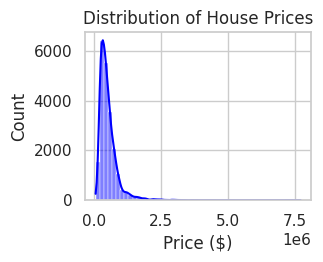

In [46]:
# 1. Distribution of Target Variable (Price)
plt.subplot(2, 2, 1)
sns.histplot(df_cleaned['price'], kde=True, bins=50, color='blue')
plt.title('Distribution of House Prices')
plt.xlabel('Price ($)')

Text(0.5, 1.0, 'Price vs. Sqft Living')

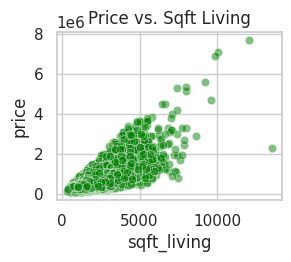

In [47]:
# 2. Relationship between Living Area and Price
plt.subplot(2, 2, 2)
sns.scatterplot(
    x='sqft_living', y='price', data=df_cleaned, alpha=0.5, color='green'
    )
plt.title('Price vs. Sqft Living')

/tmp/ipykernel_3450/597735732.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bedrooms', y='price', data=df_cleaned, palette='Set2')


Text(0.5, 1.0, 'Price by Bedrooms')

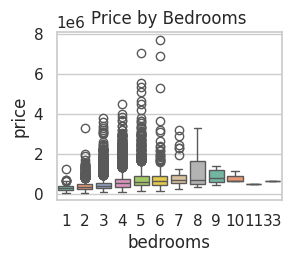

In [48]:
# 3. Bedrooms vs. Price
plt.subplot(2, 2, 3)
sns.boxplot(x='bedrooms', y='price', data=df_cleaned, palette='Set2')
plt.title('Price by Bedrooms')

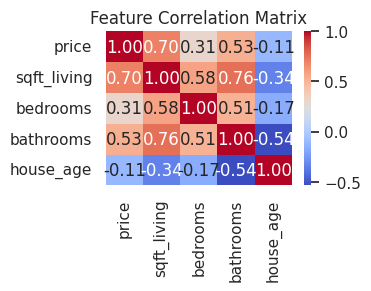

In [50]:
# 4. Correlation Heatmap for Model Features
plt.subplot(2, 2, 4)
features_corr = df_cleaned[
    ['price', 'sqft_living', 'bedrooms', 'bathrooms', 'house_age']
    ].corr()
sns.heatmap(features_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()

In [52]:
# Create a DataFrame for Model Coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
        'Coefficient ($)': model.coef_
        }).sort_values(by='Coefficient ($)', ascending=False)

print("--- Model Coefficients ---")
print(coefficients.to_string(index=False))
print(f"\nIntercept (Base Price): ${model.intercept_:,.2f}")

--- Model Coefficients ---
    Feature  Coefficient ($)
  bathrooms     74387.680612
  house_age      2623.172671
sqft_living       299.861006
   bedrooms    -67470.709643

Intercept (Base Price): $-152,203.10
